## Calculate SEMF (Semi-Emperical Mass Function)

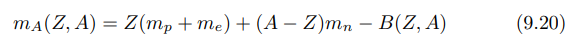
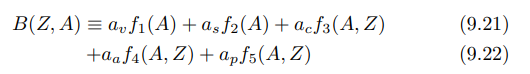

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -- Constants (MeV) --
mp = 938.272
mn = 939.565
me = 0.511
ma = 3727

class Atom:
    def __init__(self, Z, A): 
        self.A = A
        self.Z = Z
        self.N = A - Z
        self.Z_arr = np.arange(1, self.A + 1)

    def B(self, Z=None, A=None):
        if np.all(Z) == None:
            Z = self.Z
        if A == None: 
            A = self.A
        N = A - Z
        
        a_v = 15.8
        a_s = 17.8
        a_c = 0.71
        a_a = 94.8
        a_p = 11.2

        f1 = a_v * A
        f2 = -a_s * A**(2/3)
        f3 = -a_c * Z * (Z - 1) * A**(-1/3)
        f4 = -a_a * (Z - A/2)**2 / A
        
        # Initialize pairing term
        f5 = np.zeros_like(Z, dtype=float)
        
        # Boolean masks for Even-Even and Odd-Odd nuclei
        is_Z_even = (Z % 2 == 0)
        is_N_even = (N % 2 == 0)
        
        mask_pos = is_Z_even & is_N_even       # Even-Even
        mask_neg = (~is_Z_even) & (~is_N_even) # Odd-Odd
        
        # Calculate pairing strength
        # If A is 0-d (scalar), this is 0-d. If A is array, this is array.
        pairing_strength = a_p * A**(-0.5)
        
        # -- FIX IS HERE --
        # Use np.where to handle broadcasting automatically.
        # If pairing_strength is scalar/0-d, it broadcasts to fill the mask.
        # If it's an array, it maps element-wise.
        f5 = np.where(mask_pos, pairing_strength, f5)
        f5 = np.where(mask_neg, -pairing_strength, f5)

        return f1 + f2 + f3 + f4 + f5

    def m_A(self, Z=None, A=None):
        if np.all(Z) == None:
            Z = self.Z
        if A == None: 
            A = self.A
        return Z * (mp + me) + (A - Z) * mn - self.B(Z, A)
    
    def Q(self, decay):
        '''
        decay = {a, b-, b+}
        '''
        if decay == 'a':
            return self.m_A() - self.m_A(Z=self.Z-2, A=self.A-4) - ma
        if decay == 'b-':
            return self.m_A() - self.m_A(Z=self.Z+1)
        if decay == 'b+':
            return self.m_A() - self.m_A(Z=self.Z-1) - 2*me
        
    
    def alpha_t(self):
        Q = self.Q('a')

        # --- 1. Physical Constants ---
        hbar_c = 197.3      # MeV*fm
        alpha_em = 1/137    # Fine structure constant
        c = 3.0e23          # Speed of light in fm/s (approx)
        r0 = 1.2            # Radius constant in fm
        
        a = r0 * ((self.A - 4)**(1/3) + 4**1/3)
        V0 = 33 + self.B(self.Z, self.A)/self.A
        print(f'a: {a:.3g} - V0: {V0:.3g}')
        
        # -- Constants --
        ma = 3727           # MeV /c^2
        hbar_c = 197.3      # MeV*fm
        alpha_em = 1/137    # Fine structure constant 
        c = 3.0e23          # Speed of light in fm/s

        # Coulomb barrier height (B)
        B = (2 * (self.Z-2) * alpha_em * hbar_c) / a

        # The Bracket Term
        bracket_term = np.pi / 2 - 2 * np.sqrt(Q/B)

        # The Exponent Prefactor
        # 2 * sqrt(2mc^2 / hbar^2 c^2 Q) * (CoulombFactor)
        # Since CoulombFactor = B * a, we must include 'a' here.
        prefactor = 2 * (np.sqrt(2 * ma / (hbar_c**2 * Q))) * B * a 

        two_G = prefactor * bracket_term

        # Half-Life Calculation
        # Formula: 0.693 * (a/c) * sqrt(...)
        half_life_sec = 0.693 * (a / c) * np.sqrt(ma / (2*(V0 + Q))) * np.exp(two_G) 

        # -- Output --
        print(f'Half-life: {half_life_sec:.3g} seconds')
        print(f'           {half_life_sec/60/60/24:.3g} days')
        print(f'           {half_life_sec/60/60/24/365:.3g} years')


    def mass_print(self, decay=None):
        # Test Single Value
        print(f"Nuclear Mass (A={self.A}, Z={self.Z}): {self.m_A():.5f} MeV/c^2")
        print(f"Binding energy (A={self.A}, Z={self.Z}): {self.B():.5f} MeV")
        if decay: 
            print(f"Q-value (A={self.A}, Z={self.Z}): {self.Q(decay):.5f} MeV")

    def plot(self):
        # Plot
        Z_arr = np.arange(1, self.A + 1)
        m_arr = self.m_A(Z=Z_arr)
        plt.figure(figsize=(8, 5))
        plt.plot(Z_arr, m_arr, 'o-', label=f'Isobars A={self.A}')
        plt.xlabel('Proton Number Z')
        plt.ylabel('Mass (MeV/$c^2$)')
        plt.title(f'Semi-Empirical Mass Formula for A={self.A}')
        plt.grid(True)
        plt.legend()
        plt.show()

Nuclear Mass (A=13, Z=7): 12119.49475 MeV/c^2
Binding energy (A=13, Z=7): 89.37625 MeV
Q-value (A=13, Z=7): 1.81947 MeV


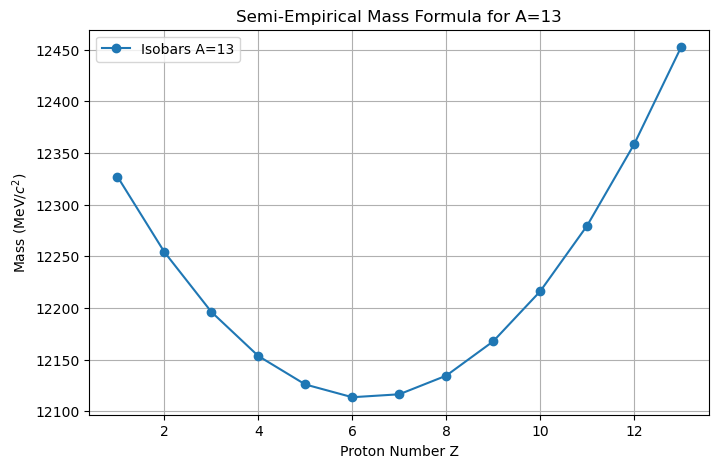

In [87]:
# -- Inputs --
A = 13                          # Atom Number
Z = 7                           # Proton Number
atom = Atom(Z, A)               # Create class
atom.mass_print(decay='b+')     # Print mass and Q with decay {'a', 'b-', 'b+'}
atom.plot()                     # Plot for SEMF at differnt Z values

In [101]:
import numpy as np

# -- Inputs --
Z = 84
Q = 5.407     # MeV
a = 7.3         # fm
V0 = 40       # MeV

# -- Constants --
ma = 3727           # MeV /c^2
hbar_c = 197.3      # MeV*fm
alpha_em = 1/137    # Fine structure constant 
c = 3.0e23          # Speed of light in fm/s

# Coulomb barrier height (B)
B = (2 * (Z-2) * alpha_em * hbar_c) / a

# The Bracket Term
bracket_term = np.pi / 2 - 2 * np.sqrt(Q/B)

# The Exponent Prefactor
# 2 * sqrt(2mc^2 / hbar^2 c^2 Q) * (CoulombFactor)
# Since CoulombFactor = B * a, we must include 'a' here.
prefactor = 2 * (np.sqrt(2 * ma / (hbar_c**2 * Q))) * B * a 

two_G = prefactor * bracket_term

# Half-Life Calculation
# Formula: 0.693 * (a/c) * sqrt(...)
half_life_sec = 0.693 * (a / c) * np.sqrt(ma / (2*(V0 + Q))) * np.exp(two_G) 

# -- Output --
print(f'Half-life: {half_life_sec:.3g} seconds')
print(f'           {half_life_sec/60/60/24:.3g} days')
print(f'           {half_life_sec/60/60/24/365:.3g} years')

Half-life: 1.29e+07 seconds
           149 days
           0.41 years
